# Random forests with the "Two Moons"

**Creating and plotting the dataset - 1000 Samples to get the idea**

Text(0.5, 1.0, '2 Moons with 1000 points')

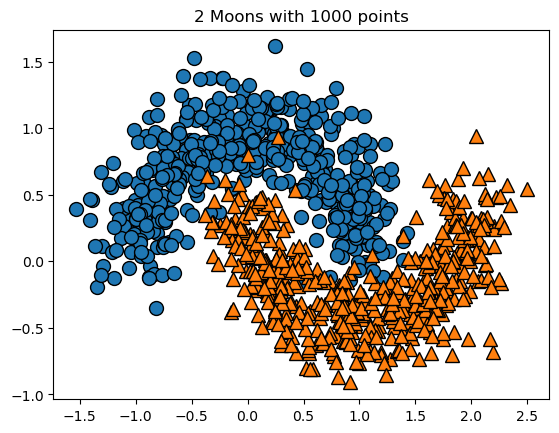

In [1]:
import mglearn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X,y = make_moons(n_samples=1000,noise=0.2, random_state=3) 
mglearn.discrete_scatter(X[:,0], X[:,1], y)
plt.title("2 Moons with 1000 points")

**Creating and plotting the moons with 100 Samples**

Text(0.5, 1.0, '2 Moons with 100 points')

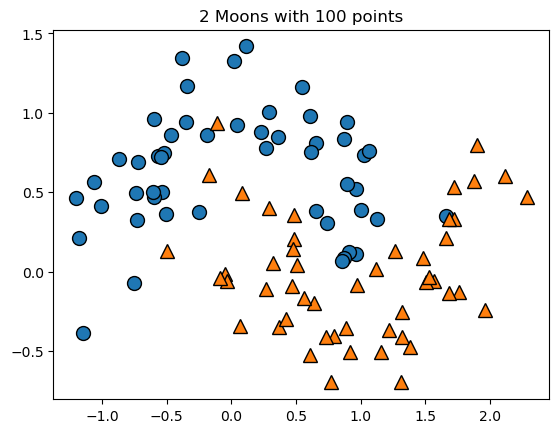

In [3]:
X,y = make_moons(n_samples=100,noise=0.25, random_state=3) 
mglearn.discrete_scatter(X[:,0], X[:,1], y)
plt.title("2 Moons with 100 points")

**Splitiing the data and Training a RandomForst**

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, stratify=y,random_state=42)

forest = RandomForestClassifier(n_estimators=5, random_state=2)
forest.fit(X_train,y_train)

print("Overall results");
print("Training score", forest.score(X_train,y_train))
print("Test score", forest.score(X_test,y_test))


Overall results
Training score 0.96
Test score 0.92


**Is the forest better than a single tree?**

In [5]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier()
tree.fit(X_train,y_train)

print("Overall results");
print("Training score", tree.score(X_train,y_train))
print("Test score", tree.score(X_test,y_test))

#can we imporove that ? 

Overall results
Training score 1.0
Test score 0.88


**Visualization of the 5 Estimators and the overall decision regions**

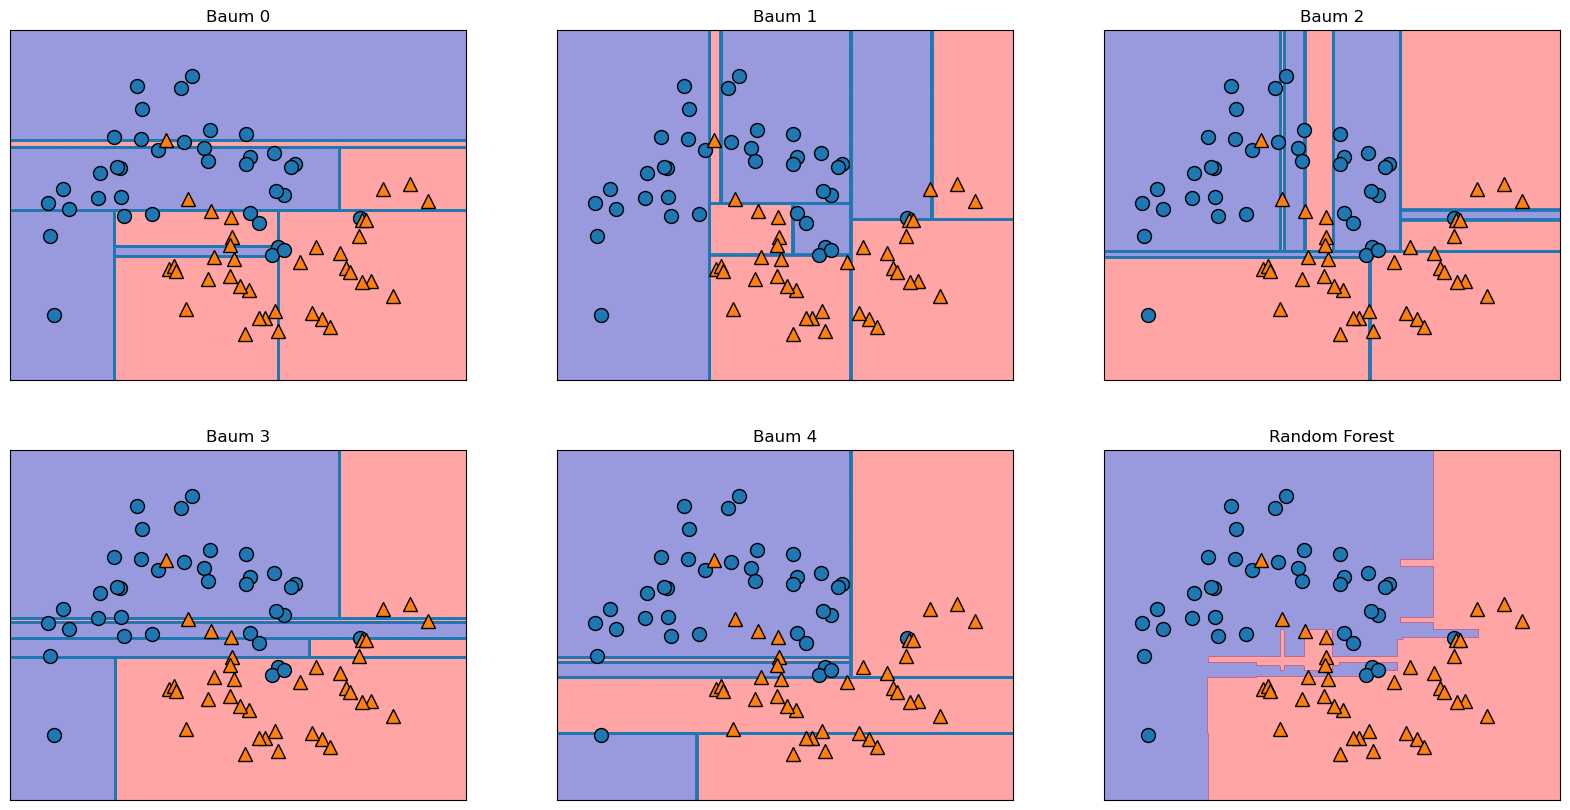

In [6]:
import matplotlib.pyplot as plt
import mglearn
import numpy as np

fig, axes = plt.subplots(2,3,figsize=(20,10))
#list(enumerate(zip(axes.ravel(), forest.estimators_)))
for i, (ax, tree) in enumerate(zip(axes.ravel(), forest.estimators_)):
    ax.set_title("Baum {}".format(i))
    mglearn.plots.plot_tree_partition(X_train, y_train, tree, ax=ax)
    
mglearn.plots.plot_2d_separator(forest, X_train, fill=True, ax=axes[-1,-1], alpha=.4)
axes[-1,-1].set_title("Random Forest")
mglearn.discrete_scatter(X_train[:,0], X_train[:,1], y_train)

**Now use the MLXtend instead of mglearn library functions**

Text(0.5, 1.0, 'Random Forest')

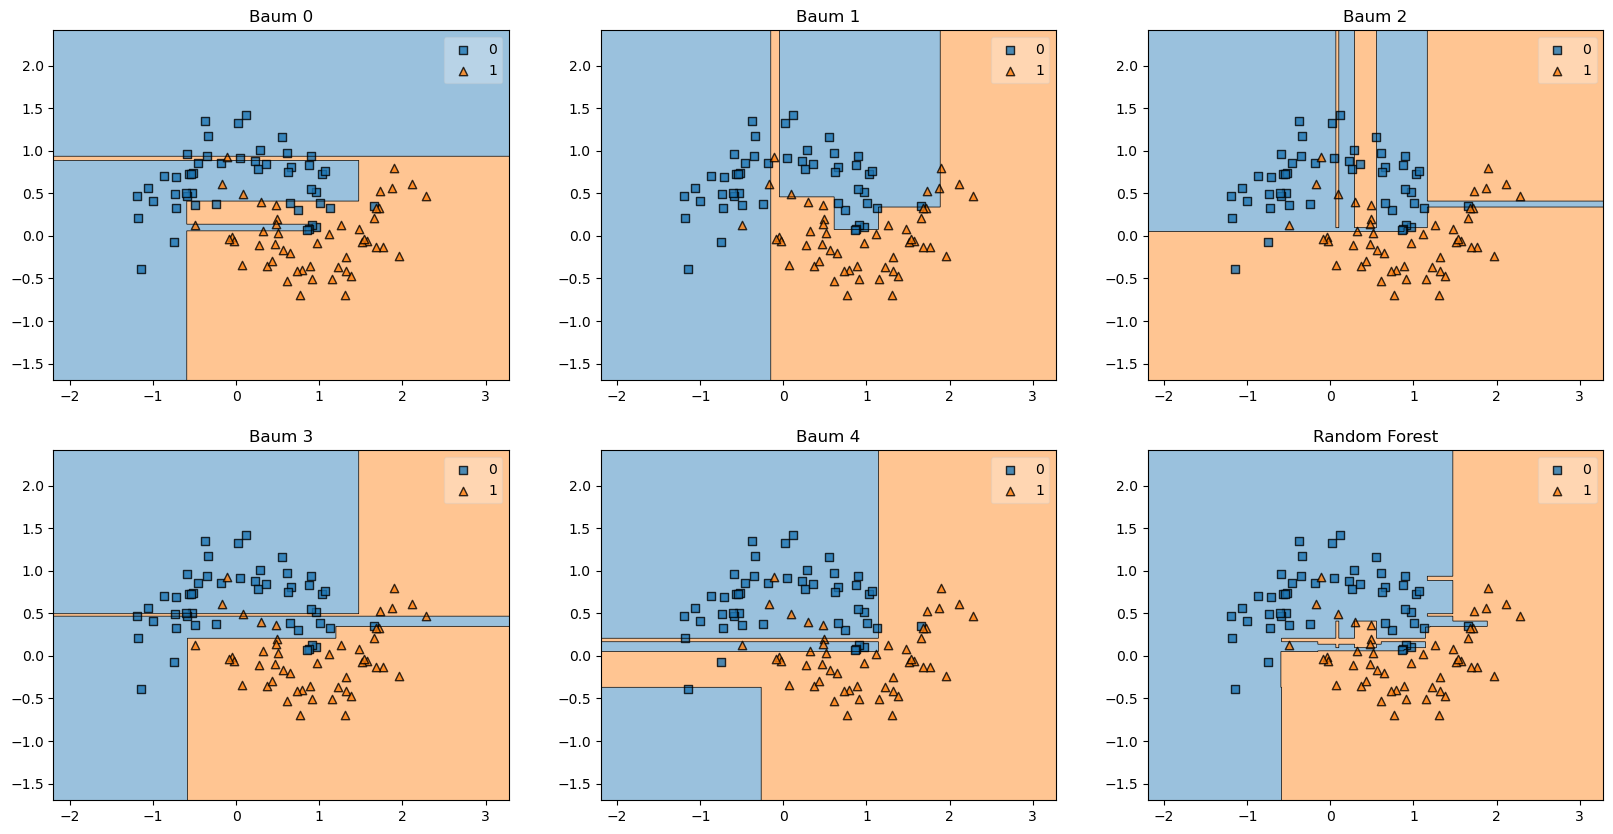

In [7]:
from mlxtend.plotting import plot_decision_regions

fig, axes = plt.subplots(2,3,figsize=(20,10))
for i, (ax, tree) in enumerate(zip(axes.ravel(), forest.estimators_)):
    ax.set_title("Baum {}".format(i))
    plot_decision_regions(X, y, clf=tree, hide_spines=False, ax=ax)

plot_decision_regions(X, y, clf=forest, hide_spines=False, ax=axes[-1,-1])
axes[-1,-1].set_title("Random Forest")

